In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
import io
import astropy.io.fits
import src.downloadCutout as downloadCutout
import src.downloadPsf as downloadPsf

from astropy.visualization import simple_norm
from astropy.modeling.models import Sersic2D
from astropy.convolution import convolve, Gaussian2DKernel
from photutils.segmentation import detect_threshold, detect_sources
import time
import statmorph

In [2]:
ra_center = 217.388809
dec_center = 1.104478
user = 'hyp0515'
password = 'PHFrCTavyczTCw/onxRGH537qhiLWqYSRuHB6WHE'
filter = 'HSC-R'

In [3]:
rect = downloadCutout.Rect.create(
    ra=	ra_center,
    dec=dec_center,
    sw="15arcsec",
    sh="15arcsec",
    variance=True,
    mask=True,
    filter=filter,
)

images = downloadCutout.download(rect, user=user, password=password)
_, image_data = images[0]
image_hdu = astropy.io.fits.open(io.BytesIO(image_data))
image_hdu.info()
image = image_hdu[1].data
mask  = image_hdu[2].data
var   = image_hdu[3].data

psfreq = downloadPsf.PsfRequest.create(
    ra=ra_center,
    dec=dec_center,
    filter=filter
)
psfs = downloadPsf.download(psfreq, user=user, password=password)
_, psf_data = psfs[0]
psf_hdu = astropy.io.fits.open(io.BytesIO(psf_data))
psf_hdu.info()
psf = psf_hdu[0].data


Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      27   ()      
  1                1 ImageHDU        44   (180, 180)   float32   
  2                1 ImageHDU        60   (180, 180)   int32   
  3                1 ImageHDU        44   (180, 180)   float32   
Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      18   (41, 43)   float64   


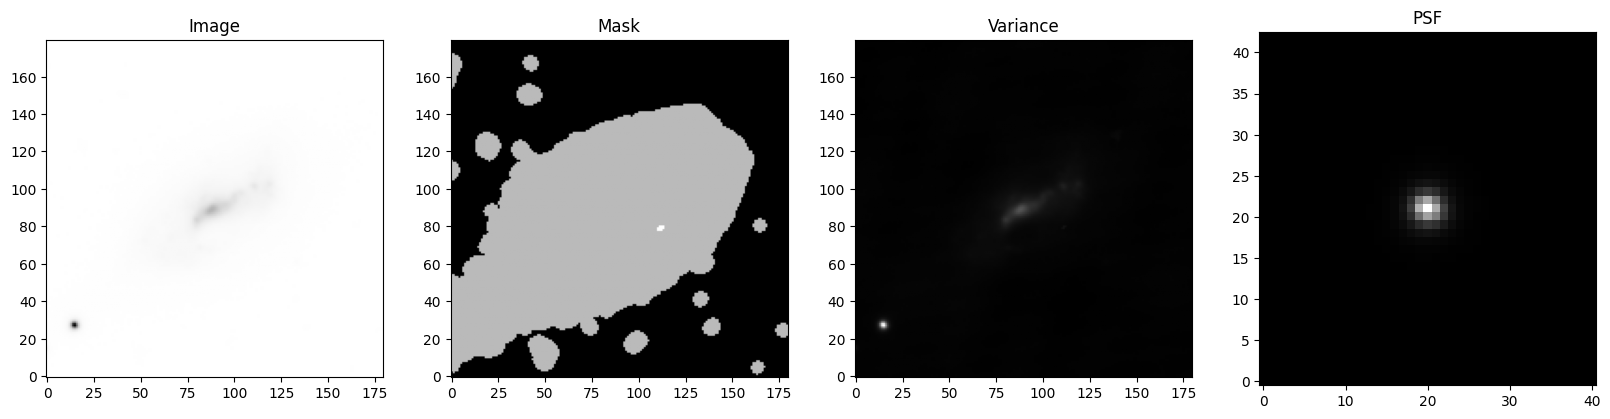

In [4]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(image, cmap="gray_r", origin="lower")
ax[0].set_title("Image")
ax[1].imshow(mask, cmap="gray", origin="lower")
ax[1].set_title("Mask")
ax[2].imshow(var, cmap="gray", origin="lower")
ax[2].set_title("Variance")
ax[3].imshow(psf, cmap="gray", origin="lower")
ax[3].set_title("PSF")
plt.show()

In [5]:
print(np.min(var), np.max(var))

0.0022405607 0.03172399


In [6]:
threshold = detect_threshold(image, 5)
npixels = 200  # minimum number of connected pixels
segmap = detect_sources(image, threshold, npixels)
segmap = np.array(segmap)
segmap = np.where(segmap != segmap[int(segmap.shape[0]/2), int(segmap.shape[1]/2)], 0, 1)
print(segmap.shape)

(180, 180)


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_63938/3495374631.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  segmap = np.array(segmap)


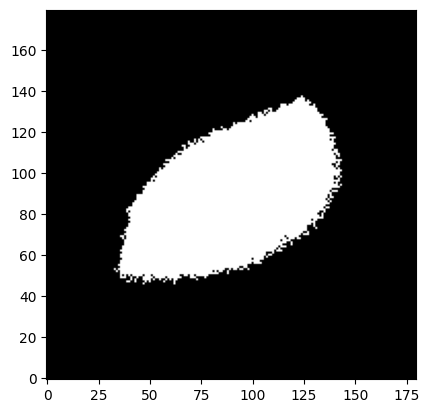

In [7]:
plt.imshow(segmap, cmap='gray', origin='lower')
plt.show()

In [8]:
start = time.time()
source_morphs = statmorph.source_morphology(image=image, segmap=segmap, psf=psf, weightmap=np.sqrt(var))
print('Time: %g s.' % (time.time() - start))

Time: 0.411372 s.


In [9]:
morph = source_morphs[0]

In [10]:
print('BASIC MEASUREMENTS (NON-PARAMETRIC)')
print('Gini =', morph.gini)
print('M20 =', morph.m20)
print('F(G, M20) =', morph.gini_m20_bulge)
print('S(G, M20) =', morph.gini_m20_merger)
print('C =', morph.concentration)
print('A =', morph.asymmetry)
print('S =', morph.smoothness)
print()
print('SERSIC MODEL')
print('sersic_amplitude =', morph.sersic_amplitude)
print('sersic_rhalf =', morph.sersic_rhalf)
print('sersic_n =', morph.sersic_n)
print('sersic_xc =', morph.sersic_xc)
print('sersic_yc =', morph.sersic_yc)
print('sersic_ellip =', morph.sersic_ellip)
print('sersic_theta =', morph.sersic_theta)
print('sersic_chi2_dof =', morph.sersic_chi2_dof)

BASIC MEASUREMENTS (NON-PARAMETRIC)
Gini = 0.49995500085729233
M20 = -1.8438104486130842
F(G, M20) = -0.20746210486753558
S(G, M20) = -0.08833420150849935
C = 3.0944082027485855
A = -2.4973501904945348
S = -1.0354356591278813

SERSIC MODEL
sersic_amplitude = 1.3261879355665935
sersic_rhalf = 46.54974907013959
sersic_n = 2.311006800210894
sersic_xc = 89.27041859672478
sersic_yc = 89.23602037208053
sersic_ellip = 0.6250451620438388
sersic_theta = 0.49380741151921537
sersic_chi2_dof = 103.62369119511428


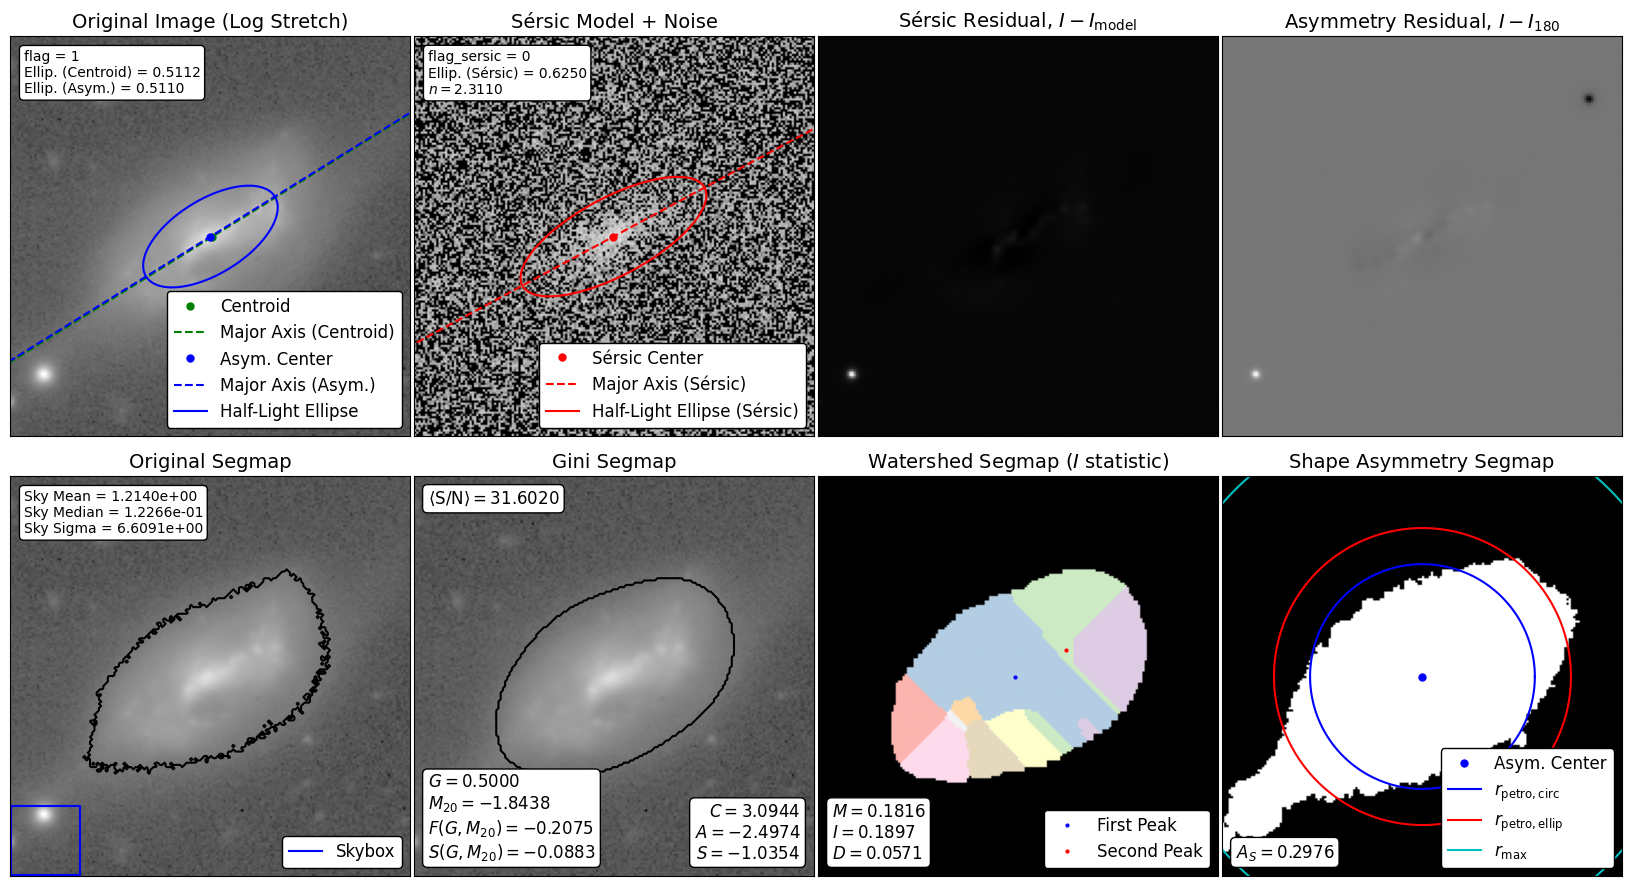

In [11]:
from statmorph.utils.image_diagnostics import make_figure
fig = make_figure(morph)

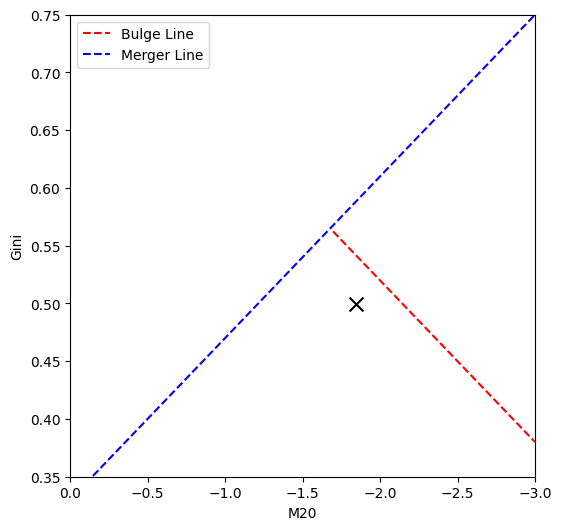

In [12]:
x = np.linspace(0, -3, 100)
merger_line = -0.14 * x + 0.33
bulge_line = 0.14 * x + 0.8
plt.figure(figsize=(6, 6))
plt.scatter(morph.m20, morph.gini, s=100, color='k', marker='x')
plt.plot(x[bulge_line<merger_line], bulge_line[bulge_line<merger_line], color='red', linestyle='--', label='Bulge Line')
plt.plot(x, merger_line, color='blue', linestyle='--', label='Merger Line')
plt.xlim((0, -3))
plt.ylim((0.35, 0.75))
plt.xlabel('M20')
plt.ylabel('Gini')
plt.legend()
plt.show()

In [ ]:
print(-0.693*morph.m20 + 4.95*morph.gini -3.96)
print(0.139*morph.m20 + 0.990*morph.gini -0.327)

-0.20746210486753558
-0.08833420150849935
